# Task 3 — Regression, Classification, Clustering, PCA & Pipelines
10 questions across 5 sections. 100 points total.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.datasets import load_breast_cancer, make_blobs
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay,
                              r2_score, mean_absolute_error, mean_squared_error, silhouette_score)

np.random.seed(42)

---
## 1. Regression (20 points)

### Q1 — Linear Regression from Scratch (10 points)
Implement using the Normal Equation, then compare with sklearn's `LinearRegression`.

**a.** Add a column of ones to X for the bias term.

In [2]:
X = np.array([[2],[3],[5],[7],[9],[11],[13]])
y = np.array([55, 62, 73, 80, 88, 92, 95])

X_B = np.c_[np.ones((X.shape[0], 1)), X]

**b.** Compute theta using the Normal Equation.

In [3]:
theta = np.linalg.inv(X_B.T.dot(X_B)).dot(X_B.T).dot(y)

**c.** Print the intercept and slope.

In [4]:
print(f"Intercept: {theta[0]:.4f}")
print(f"Slope: {theta[1]:.4f}")

Intercept: 51.8555
Slope: 3.6402


**d.** Predict the score for 8 hours of study.

In [5]:
hours = 8
predicted_score = theta[0] + theta[1] * hours
print(f"Predicted score for {hours} hours of study: {predicted_score:.2f}")

Predicted score for 8 hours of study: 80.98


**e.** Do the same with sklearn and print both results side by side.

In [6]:
sklearn_model = LinearRegression()
sklearn_model.fit(X, y)

print("--- Comparison ---")
print(f"From scratch  -> Intercept: {theta[0]:.4f}, Slope: {theta[1]:.4f}")
print(f"Sklearn       -> Intercept: {sklearn_model.intercept_:.4f}, Slope: {sklearn_model.coef_[0]:.4f}")

sklearn_pred = sklearn_model.predict([[8]])[0]
print(f"\nFrom scratch prediction (8 hrs): {predicted_score:.2f}")
print(f"Sklearn prediction (8 hrs): {sklearn_pred:.2f}")

--- Comparison ---
From scratch  -> Intercept: 51.8555, Slope: 3.6402
Sklearn       -> Intercept: 51.8555, Slope: 3.6402

From scratch prediction (8 hrs): 80.98
Sklearn prediction (8 hrs): 80.98


### Q2 — Polynomial Regression (10 points)
Fit degree=3 polynomial regression on the same data.

**a-d.** Plot original data (red circles), polynomial curve (blue line), linear regression line (dashed gray)

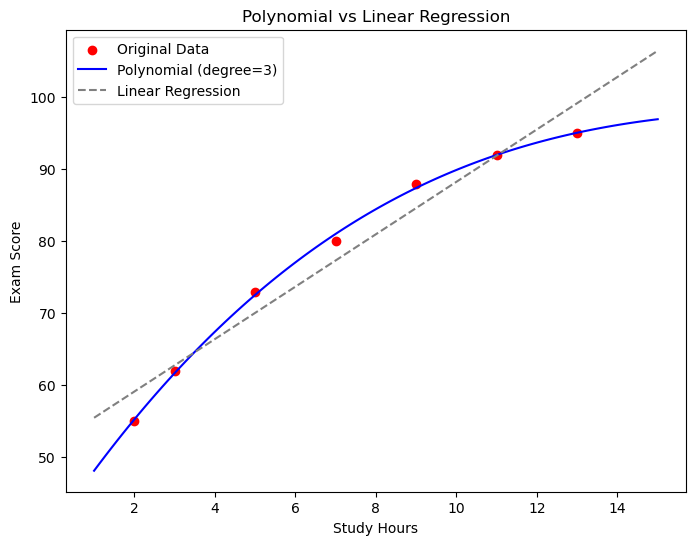

In [7]:
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

linear_model = LinearRegression()
linear_model.fit(X, y)


X_new = np.linspace(1, 15, 100).reshape(-1, 1)
X_new_poly = poly.transform(X_new)

y_new_poly = poly_model.predict(X_new_poly)
y_new_linear = linear_model.predict(X_new)


plt.figure(figsize=(8, 6))
plt.scatter(X, y, color='red', label='Original Data')
plt.plot(X_new, y_new_poly, color='blue', label='Polynomial (degree=3)')
plt.plot(X_new, y_new_linear, color='gray', linestyle='--', label='Linear Regression')

plt.title('Polynomial vs Linear Regression')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.legend()
plt.show()

**e.** Print the R² score of both models. Which fits better and why?

In [8]:
r2_poly = r2_score(y, poly_model.predict(X_poly))
r2_linear = r2_score(y, linear_model.predict(X))

print(f"Polynomial R²: {r2_poly:.4f}")
print(f"Linear R²: {r2_linear:.4f}")

Polynomial R²: 0.9987
Linear R²: 0.9554


*by the numbers alone Polynomial performerd alot better at 0.9987 than the Linear's 0.9554 but i also have to mention that since this is barely a 7 row matrix a polynomial of a third degree has much more room to bend that doesn't mean that this relation ship is actually cubic or not! it's just at such small values it was likely that it would score higher eitherway due to it's nature*

---
## 2. Classification (30 points)

### Setup — Breast Cancer Dataset (shared across Q3-Q5)

In [9]:
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.25, random_state=42, stratify=data.target
)

### Q3 — Logistic Regression Pipeline (10 points)

**a.** Build a pipeline: StandardScaler → LogisticRegression(max_iter=1000).

In [10]:
log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000))
])

**b.** Fit on training data and predict on test data.

In [11]:
log_reg_pipe.fit(X_train, y_train)
y_pred = log_reg_pipe.predict(X_test)

**c.** Print Accuracy, Precision, Recall, F1-Score (classification_report).

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        53
           1       0.99      0.99      0.99        90

    accuracy                           0.99       143
   macro avg       0.99      0.99      0.99       143
weighted avg       0.99      0.99      0.99       143



**d.** Get prediction probabilities. Try thresholds [0.3, 0.5, 0.7]. Print precision/recall for each.

In [13]:
y_proba = log_reg_pipe.predict_proba(X_test)[:, 1]

for threshold in [0.3, 0.5, 0.7]:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    print(f"Threshold {threshold}: Precision={prec:.3f}, Recall={rec:.3f}")

Threshold 0.3: Precision=0.968, Recall=1.000
Threshold 0.5: Precision=0.989, Recall=0.989
Threshold 0.7: Precision=0.988, Recall=0.933


**e.** Which threshold would you recommend for a medical diagnosis and why?

*in any normal model i'd reccomend the threshhold at 0.5 due to the best balance of Precision & Recall but since this is such a crucial topic i'd have to reccomend the threshold be at 0.3 since recall is at 1.00 and precision is still above even good but not as good a balance as 0.5 threshhold but i'd rather tell someone with a benign tumor theat it's malignant rather than the opposite since one's consequence is emotional pain and inconvenience while the other is life & death so to me the choice is clear*

### Q4 — Decision Tree Classifier (10 points)
max_depth=4, random_state=42.

**a.** Fit the model (no scaling needed for trees).

In [14]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**b.** Print the top 5 most important features with their importance scores, sorted descending.

In [15]:
importances = pd.Series(dt_model.feature_importances_, index=data.feature_names)
top5 = importances.sort_values(ascending=False).head(5)
print(top5)

worst radius            0.726829
worst concave points    0.122113
texture error           0.048398
worst texture           0.033231
worst concavity         0.018188
dtype: float64


**c.** Plot a horizontal bar chart of the top 10 features by importance.

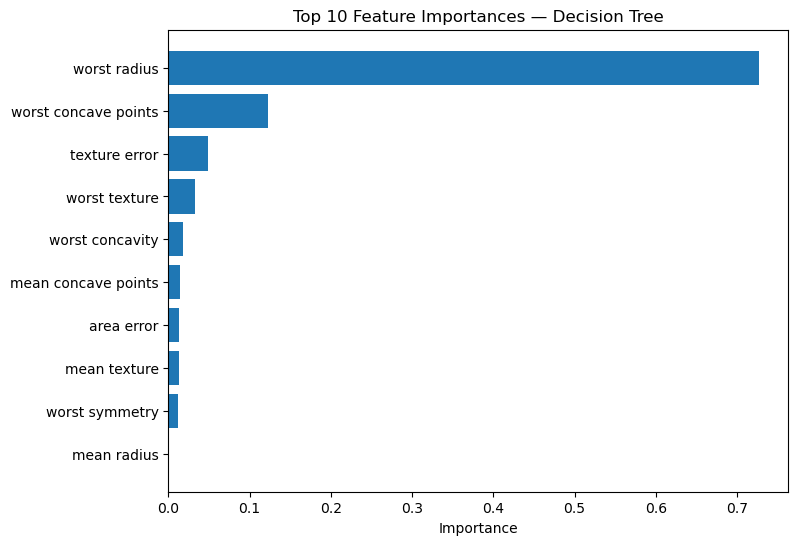

In [16]:
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 6))
plt.barh(top10.index[::-1], top10.values[::-1])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances — Decision Tree')
plt.show()

**d.** Print accuracy on both train and test sets. Is there a gap? What does it indicate?

In [17]:
train_acc = accuracy_score(y_train, dt_model.predict(X_train))
test_acc = accuracy_score(y_test, dt_model.predict(X_test))

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Gap: {train_acc - test_acc:.4f}")

Train Accuracy: 0.9883
Test Accuracy: 0.9441
Gap: 0.0442


*the acc of the test being ~95% is good enough since this dataset is so big it could actually work on muh more depth and a gap of 4.4% is actually quite good if it was more by let's say 10% it would be close to overfitting but because depth was capped at 4 it shows actual pattern analysis since it didn't have enough time to memorize the data also this is optimal cause if gap was smaller that would actually show underfitting*

### Q5 — Random Forest Classifier (10 points)
n_estimators=200, max_depth=10, random_state=42.

**a.** Fit, predict, and print the confusion matrix (ConfusionMatrixDisplay).

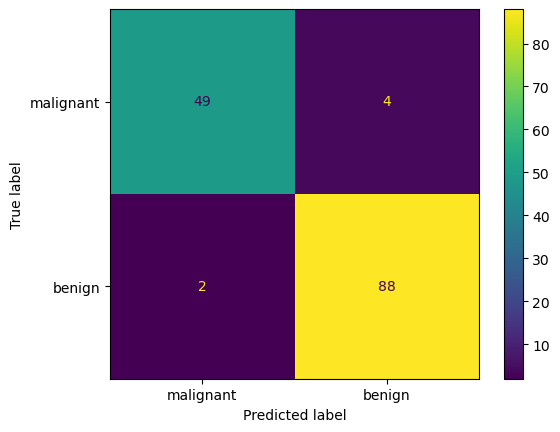

In [18]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot()
plt.show()

**b.** Extract TP, TN, FP, FN and compute precision, recall, F1 manually. Verify against sklearn.

In [19]:
tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")

manual_precision = tp / (tp + fp)
manual_recall = tp / (tp + fn)
manual_f1 = 2 * (manual_precision * manual_recall) / (manual_precision + manual_recall)

print(f"\nManual Precision: {manual_precision:.4f}")
print(f"Manual Recall: {manual_recall:.4f}")
print(f"Manual F1: {manual_f1:.4f}")

sklearn_precision = precision_score(y_test, y_pred_rf)
sklearn_recall = recall_score(y_test, y_pred_rf)
sklearn_f1 = f1_score(y_test, y_pred_rf)

print(f"\nSklearn Precision: {sklearn_precision:.4f}")
print(f"Sklearn Recall: {sklearn_recall:.4f}")
print(f"Sklearn F1: {sklearn_f1:.4f}")

TP=88, TN=49, FP=4, FN=2

Manual Precision: 0.9565
Manual Recall: 0.9778
Manual F1: 0.9670

Sklearn Precision: 0.9565
Sklearn Recall: 0.9778
Sklearn F1: 0.9670


**c.** Perform 5-Fold Stratified Cross-Validation, print mean accuracy ± std.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='accuracy')

print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

CV Accuracy: 0.9648 ± 0.0196


---
## 3. KNN & Clustering (20 points)

### Q6 — Optimal K for KNN (10 points)
Using the breast cancer dataset (scaled with StandardScaler).

**a.** Scale the data first (fit on train only).

In [21]:
knn_scaler = StandardScaler()
X_train_scaled = knn_scaler.fit_transform(X_train)
X_test_scaled = knn_scaler.transform(X_test)

**b.** Loop K = 1 to 30. For each K, train KNeighborsClassifier and record test accuracy.

In [22]:
ks = []
accuracies = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test_scaled))
    ks.append(k)
    accuracies.append(acc)

**c.** Plot K vs accuracy as a line chart with markers.

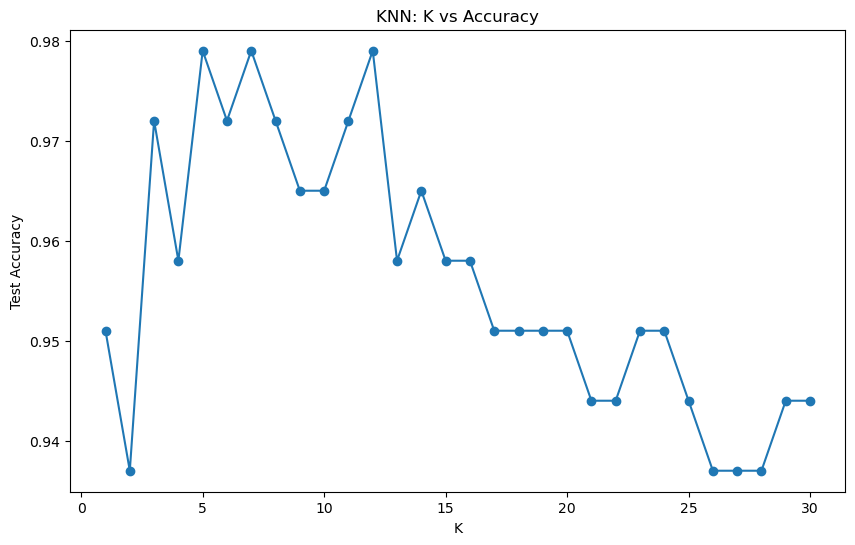

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(ks, accuracies, 'o-')
plt.xlabel('K')
plt.ylabel('Test Accuracy')
plt.title('KNN: K vs Accuracy')
plt.show()

**d.** Print the best K and its accuracy.

In [24]:
best_k = ks[np.argmax(accuracies)]
best_acc = max(accuracies)

print(f"Best K: {best_k}, Accuracy: {best_acc:.4f}")

Best K: 5, Accuracy: 0.9790


**e.** Train KNN with the best K and print the full classification report.

In [25]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        53
           1       0.97      1.00      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.97      0.98       143
weighted avg       0.98      0.98      0.98       143



### Q7 — K-Means Clustering (10 points)
make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42).

**a.** Run K-Means with K = 2, 3, 4, 5, 6. Compute and print inertia for each.

In [26]:
X_blobs, y_blobs = make_blobs(n_samples=300, centers=4, cluster_std=1.2, random_state=42)

inertias = []
k_values = [2, 3, 4, 5, 6]

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_blobs)
    inertias.append(km.inertia_)
    print(f"K={k}: Inertia={km.inertia_:.2f}")

K=2: Inertia=9666.83
K=3: Inertia=2346.88
K=4: Inertia=805.48
K=5: Inertia=729.97
K=6: Inertia=656.62


c:\Users\oufyw\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\oufyw\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\oufyw\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\oufyw\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

**b.** Plot the Elbow Curve (K vs inertia).

In [27]:
train_acc = accuracy_score(y_train, dt_model.predict(X_train))
test_acc = accuracy_score(y_test, dt_model.predict(X_test))

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Gap: {train_acc - test_acc:.4f}")

Train Accuracy: 0.9883
Test Accuracy: 0.9441
Gap: 0.0442


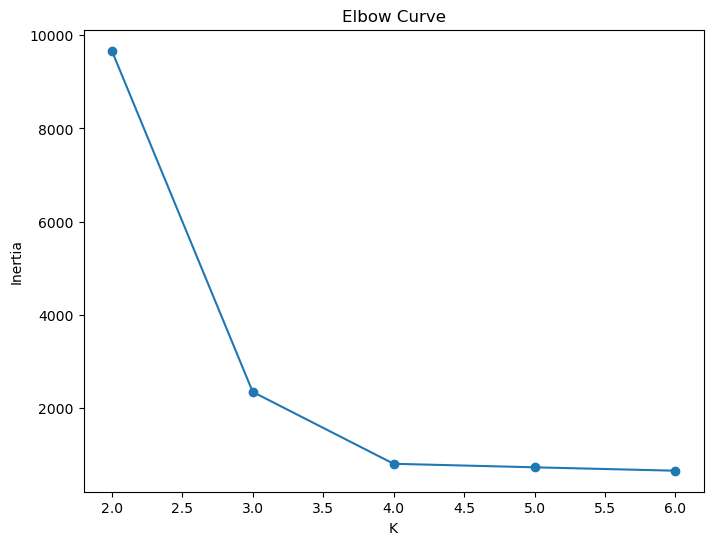

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertias, 'o-')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Curve')
plt.show()

**c.** From the elbow, pick the best K and re-run K-Means with that K.

In [29]:
best_k_kmeans = 4  # confirm this against what your own elbow plot shows

km_final = KMeans(n_clusters=best_k_kmeans, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_blobs)

c:\Users\oufyw\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


**d.** Scatter plot colored by cluster label. Centroids as red X markers, size 150.

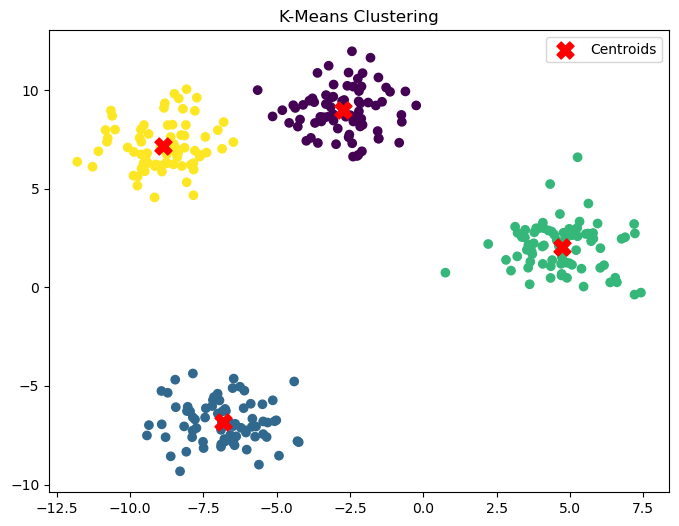

In [30]:
plt.figure(figsize=(8, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=cluster_labels, cmap='viridis')
plt.scatter(km_final.cluster_centers_[:, 0], km_final.cluster_centers_[:, 1],
            c='red', marker='X', s=150, label='Centroids')
plt.legend()
plt.title('K-Means Clustering')
plt.show()

**e.** Print the Silhouette Score for the best K.

In [31]:
sil_score = silhouette_score(X_blobs, cluster_labels)
print(f"Silhouette Score: {sil_score:.4f}")

Silhouette Score: 0.7518


---
## 4. PCA & Pipelines (20 points)

### Q8 — PCA Dimensionality Reduction (10 points)
Using the breast cancer dataset (30 features).

**a.** Scale the data with StandardScaler.

In [32]:
pca_scaler = StandardScaler()
X_scaled_full = pca_scaler.fit_transform(data.data)

**b.** Fit PCA on the scaled data. Print explained variance ratio for the first 10 components.

In [33]:
pca_full = PCA()
pca_full.fit(X_scaled_full)
print("Explained variance ratio (first 10):")
print(pca_full.explained_variance_ratio_[:10])

Explained variance ratio (first 10):
[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734 0.01588724 0.01389649 0.01168978]


**c.** Plot cumulative explained variance, with a horizontal dashed line at 0.95.

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'o-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance')
plt.legend()
plt.show()

NameError: name 'cumulative_variance' is not defined

<Figure size 1000x600 with 0 Axes>

**d.** How many components are needed to explain ≥95% of the variance?

In [ ]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")


**e.** Transform to 2 principal components. Scatter plot colored by target class, with legend.

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled_full)

plt.figure(figsize=(10, 6))
for label, name in zip([0, 1], data.target_names):
    mask = data.target == label
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], label=name, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Breast Cancer Data — 2 Principal Components')
plt.legend()
plt.show()

**f.** Take the first test sample, reduce to 2D, reconstruct to 30D. Print the MSE.

In [ ]:
X_test_scaled_full = pca_scaler.transform(X_test)
sample_2d = pca_2d.transform(X_test_scaled_full[0:1])
sample_reconstructed = pca_2d.inverse_transform(sample_2d)

mse_reconstruction = mean_squared_error(X_test_scaled_full[0], sample_reconstructed[0])
print(f"Reconstruction MSE: {mse_reconstruction:.4f}")

### Q9 — Full Pipeline: Scaler → PCA → SVC (10 points)

**a.** Construct the pipeline with steps named 'scaler', 'pca', 'svc'.

In [ ]:
full_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svc', SVC(kernel='rbf'))
])


**b.** Fit on training data and predict on test data.

In [ ]:
full_pipe.fit(X_train, y_train)
y_pred_pipe = full_pipe.predict(X_test)

**c.** Print the classification report.

In [ ]:
print(classification_report(y_test, y_pred_pipe))

**d.** cross_val_score with cv=5, scoring='f1_macro'. Print mean ± std.

In [ ]:
cv_f1_scores = cross_val_score(full_pipe, X_train, y_train, cv=5, scoring='f1_macro')
print(f"CV F1-macro: {cv_f1_scores.mean():.4f} ± {cv_f1_scores.std():.4f}")

**e.** Access the fitted PCA step and print how many components it kept.

In [ ]:
n_kept = full_pipe.named_steps['pca'].n_components_
print(f"Components kept: {n_kept}")

---
## End-to-End Challenge — Q10 (10 points)
Housing dataset. Assume: 5000 rows, `location` has 4 unique values, `area` has 50 missing values, no other missing data.

**a.** Load & inspect: shape, info(), describe(), isnull().sum().

In [ ]:
df = pd.read_csv("housing.csv")

print(df.shape)
df.info()
print(df.describe())
print(df.isnull().sum())

**b.** Handle missing values: fill missing `area` with the median.

In [ ]:
numeric_features = ['area', 'bedrooms', 'bathrooms', 'floors']
categorical_features = ['location']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

**c.** Encode categoricals: OneHotEncoder(drop='first') on `location`.

**d.** Build a ColumnTransformer: SimpleImputer + StandardScaler on numeric, OneHotEncoder on categorical.

**e.** Build a Pipeline: ColumnTransformer → RandomForestRegressor(n_estimators=100, random_state=42).

In [ ]:
housing_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])


**f.** Train & evaluate: 80/20 split. Print MAE, RMSE, R² on the test set.

In [ ]:
X_housing = df[numeric_features + categorical_features]
y_housing = df['price']

X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

housing_pipe.fit(X_h_train, y_h_train)
y_h_pred = housing_pipe.predict(X_h_test)

mae = mean_absolute_error(y_h_test, y_h_pred)
rmse = np.sqrt(mean_squared_error(y_h_test, y_h_pred))
r2 = r2_score(y_h_test, y_h_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

**g.** Feature importance: extract and print the top 5 features with their importance scores.

In [ ]:
feature_names_out = housing_pipe.named_steps['preprocessor'].get_feature_names_out()
importances_housing = housing_pipe.named_steps['regressor'].feature_importances_

importance_series = pd.Series(importances_housing, index=feature_names_out)
print(importance_series.sort_values(ascending=False).head(5))